In [1]:
from src.measure_ir import *

import matplotlib.pyplot as plt
import numpy as np
from src.audio_device import AudioDevice
import soundfile as sf
from src.real_time import RealtimeFxLMS

In [2]:
fs = 48000
ad = AudioDevice(fs)

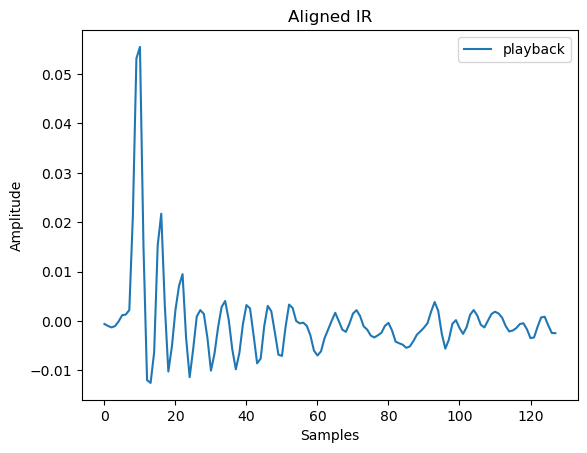

In [9]:
ir_len = 128
panel_to_err_cm = 7

error_ir, _ = measure_ir(ad)
panel_ir = align_ir_by_distance(error_ir, panel_to_err_cm, ir_len)

plt.plot(panel_ir, label="playback")

plt.xlabel('Samples')
plt.ylabel('Amplitude')
plt.title('Aligned IR')
plt.legend()
plt.show()

In [10]:
arthur, fs = sf.read('data/arthur_clip_48k.wav')
rt = RealtimeFxLMS(ad, source=arthur, ir=panel_ir, block_size=1024)

Lag from cross-correlation: 4446
Delay from device: 4312


In [26]:
arthur_repeated = np.tile(arthur, 20)
rt = RealtimeFxLMS(ad, source=arthur_repeated, ir=panel_ir, block_size=64)

Lag from cross-correlation: 504
Delay from device: 376


In [41]:
sf.write('error_mic.wav', rt.error_log, ad.fs)

In [42]:
sf.write('no_cancel.wav', rt.error_nc, ad.fs)

db_redux: -2.22647


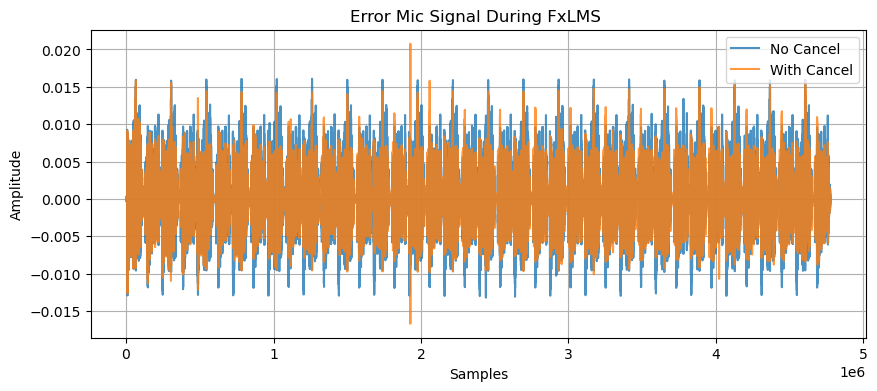

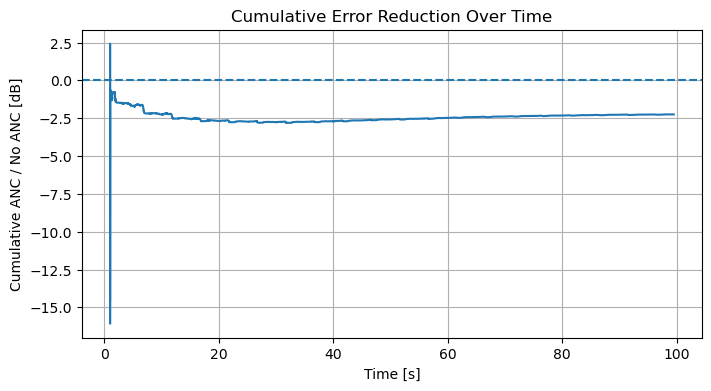

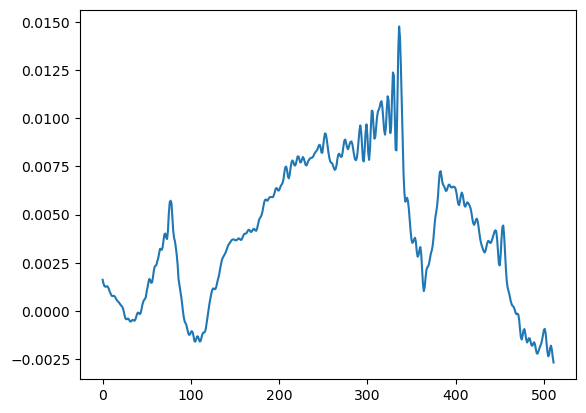

In [40]:
rt.reset(lag=rt.system_lag, block_size=64, filter_order=512)

step_fn = lambda t: 1e-4 / np.sqrt(1 + t / 50000)

error, cancel, *_ = rt.run(
    cancel_gain=0.25,  
    fx=True,
    nlms=True,
    clean_source=True,
    step_fn=step_fn,
    leak=1e-7,
    max_norm=1.0,
)

print('db_redux:', rt.db_reduction)

rt.plot_error_mic()
rt.plot_cumulative_error_reduction()

plt.plot(rt.w)

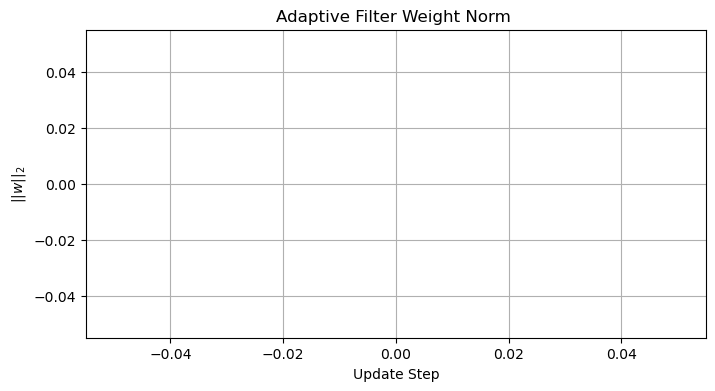

In [ ]:
rt.plot_w_norm()

In [9]:
rt = RealtimeFxLMS(ad, source=arthur, ir=panel_ir, block_size=64)

delays = range(0, 512, 8)
c_gains = [.1, 0.15, 0.2, 0.25]
signs = [0.1, -0.1]

for d in delays:
    for c_gain in c_gains:
        for sign in signs:
            rt.reset(filter_order=512)
            rt.w[d] = sign

            error, cancel, *_ = rt.run(
                cancel_gain=c_gain,
                fx=False,
                nlms=False,
                clean_source=True,
                step_fn=0,
                leak=0,
                max_norm=0.0,
            )

            print('d:', d, 'c_gain:', c_gain, 'sign:', sign, 'db_redux:', rt.db_reduction)

Lag from cross-correlation: 826
Delay from device: 376
d: 0 c_gain: 0.1 sign: 0.1 db_redux: 0.123642825
d: 0 c_gain: 0.1 sign: -0.1 db_redux: 0.21977188
d: 0 c_gain: 0.15 sign: 0.1 db_redux: 0.30653754
d: 0 c_gain: 0.15 sign: -0.1 db_redux: 0.4936895
d: 0 c_gain: 0.2 sign: 0.1 db_redux: 0.58238006
d: 0 c_gain: 0.2 sign: -0.1 db_redux: 0.79715824
d: 0 c_gain: 0.25 sign: 0.1 db_redux: 0.8883
d: 0 c_gain: 0.25 sign: -0.1 db_redux: 1.1780536
d: 8 c_gain: 0.1 sign: 0.1 db_redux: 0.06965556
d: 8 c_gain: 0.1 sign: -0.1 db_redux: 0.27944696
d: 8 c_gain: 0.15 sign: 0.1 db_redux: 0.2612387
d: 8 c_gain: 0.15 sign: -0.1 db_redux: 0.54640245
d: 8 c_gain: 0.2 sign: 0.1 db_redux: 0.49717718
d: 8 c_gain: 0.2 sign: -0.1 db_redux: 0.87302446
d: 8 c_gain: 0.25 sign: 0.1 db_redux: 0.8299594
d: 8 c_gain: 0.25 sign: -0.1 db_redux: 1.2576787
d: 16 c_gain: 0.1 sign: 0.1 db_redux: 0.07140773
d: 16 c_gain: 0.1 sign: -0.1 db_redux: 0.28968206
d: 16 c_gain: 0.15 sign: 0.1 db_redux: 0.2455835
d: 16 c_gain: 0.15 si

In [10]:
arthur_repeated = np.tile(arthur, 20)
rt = RealtimeFxLMS(ad, source=arthur_repeated, ir=panel_ir, block_size=64)

Lag from cross-correlation: 826
Delay from device: 376


db_redux: 14.954319


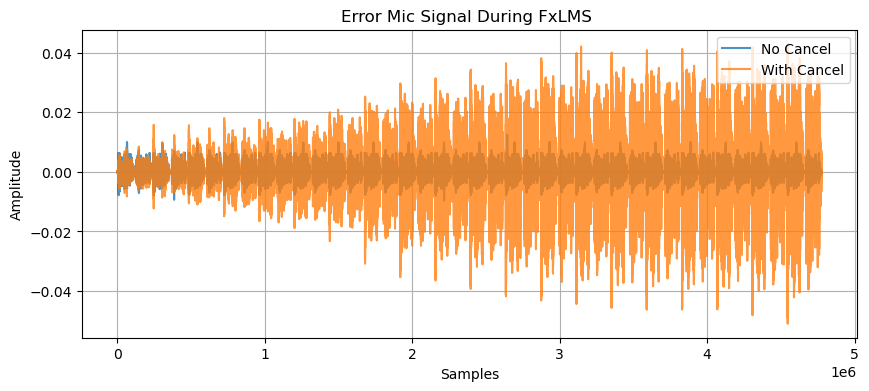

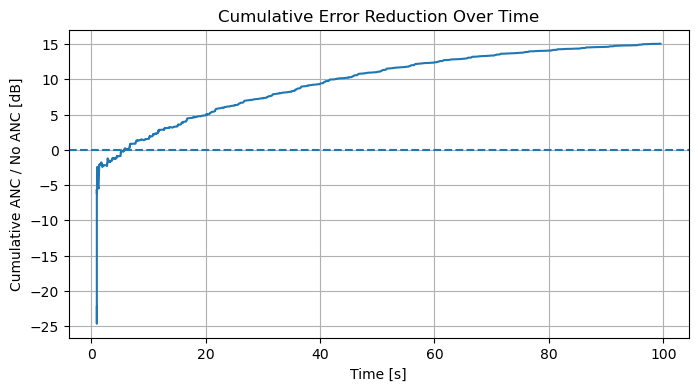

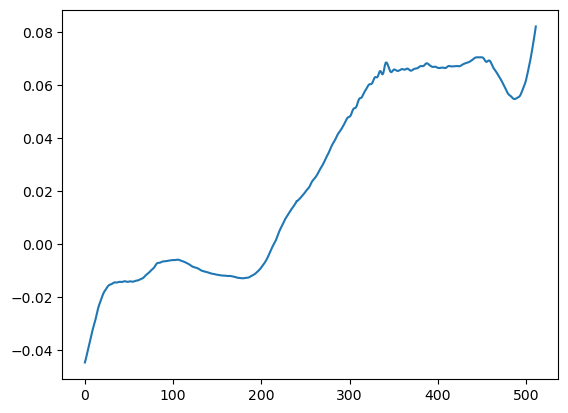

In [14]:
rt.reset(lag=rt.system_lag, block_size=64, filter_order=512)
rt.w[240] = 0.2


step_fn = lambda t: 1e-3 / np.sqrt(1 + t / 2000)

error, cancel, *_ = rt.run(
    cancel_gain=0.25,  
    fx=True,
    nlms=True,
    clean_source=True,
    step_fn=step_fn,
    leak=1e-7,
    max_norm=1.0,
)

print('db_redux:', rt.db_reduction)

rt.plot_error_mic()
rt.plot_cumulative_error_reduction()

plt.plot(rt.w)